<a href="https://colab.research.google.com/github/Anindri/NPTEL_OptimizationInML/blob/main/W2_L1_MLOptmz_NPTEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def pltvec(v,c,alpha):
  plt.figure()
  plt.axvline(x=0, color='gray', zorder=0)
  plt.axhline(y=0, color='gray', zorder=0)

  for i in range(len(v)):
    x=np.concatenate([[0,0],v[i]])
    plt.quiver([x[0]],
               [x[1]],
               [x[2]],
               [x[3]],
               angles='xy',scale_units='xy', scale=1, color=c[i],
               alpha=alpha)

In [4]:
A=np.array([[-1,3],[2,-2]])
v=np.array([[2],[1]])

In [5]:
A

array([[-1,  3],
       [ 2, -2]])

In [11]:
v

array([[2],
       [1]])

(-1.0, 4.0)

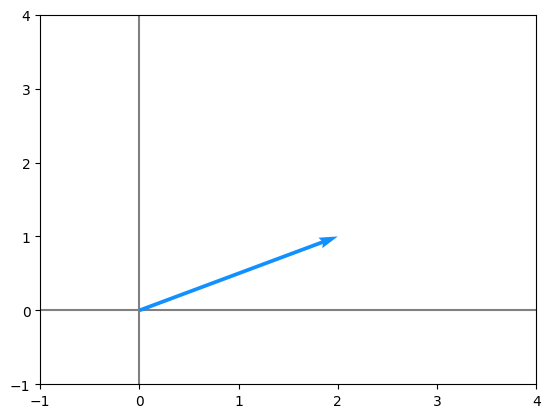

In [6]:
pltvec([v.flatten()], c=['#1190FF'],alpha=1)
plt.ylim(-1,4)
plt.xlim(-1,4)

(-1.0, 7.0)

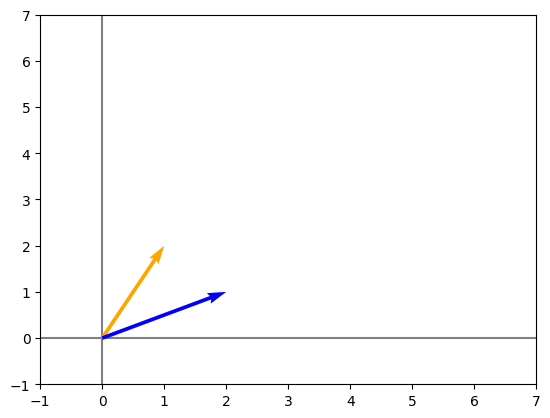

In [10]:
Av=A.dot(v)

pltvec([Av.flatten(), v.flatten()], c=['orange','blue'],alpha=1)
plt.ylim(-1,7)
plt.xlim(-1,7)

In [14]:
A_=np.array([[5,1],[3,3]])
v_=np.array([[1],[1]]) #eigenvector of A_

(-1.0, 7.0)

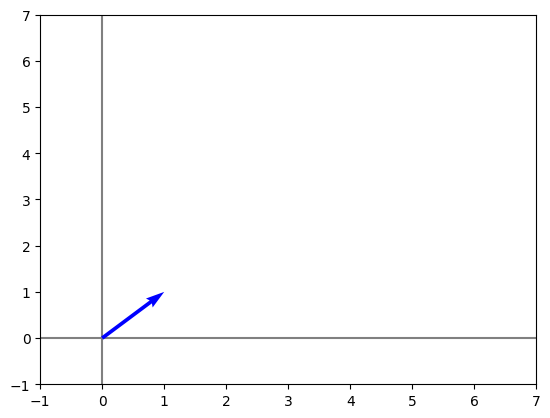

In [15]:
pltvec([v_.flatten()],c=['blue'],alpha=1)
plt.ylim(-1,7)
plt.xlim(-1,7)

In [16]:
Av_=A_.dot(v_)

(-1.0, 7.0)

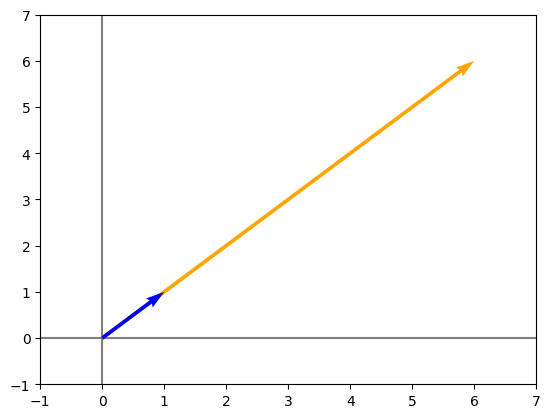

In [17]:
pltvec([Av_.flatten(),v_.flatten()],c=['orange','blue'],alpha=1)
plt.ylim(-1,7)
plt.xlim(-1,7)

In [32]:
L,U=np.linalg.eig(A_)
L

array([6., 2.])

In [33]:
U

array([[ 0.70710678, -0.31622777],
       [ 0.70710678,  0.9486833 ]])

In [34]:
v_  #same as the first eigen vector in U i.e. first column

array([[1],
       [1]])

In [18]:
#EVD

In [19]:
M=np.array([[1,2,1],[0,1,0],[1,0,1]])
Lambda,U=np.linalg.eig(M)
print(Lambda)
print(U)

[2. 0. 1.]
[[ 7.07106781e-01 -7.07106781e-01  2.00093587e-17]
 [ 0.00000000e+00  0.00000000e+00  4.47213595e-01]
 [ 7.07106781e-01  7.07106781e-01 -8.94427191e-01]]


In [21]:
#convert Lambda to diagonal matrix form
Lambdad=np.diag(Lambda)
Lambdad

array([[2., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.]])

In [23]:
#find U^-1
U_inv=np.linalg.inv(U)
U_inv

array([[ 0.70710678,  1.41421356,  0.70710678],
       [-0.70710678,  1.41421356,  0.70710678],
       [ 0.        ,  2.23606798,  0.        ]])

In [31]:
EVD=np.dot(U,np.dot(Lambdad,U_inv))

def round(val,decs=0): #to exclude decimal points in the matrix
  return np.round(val*10**decs)/(10**decs)
res=round(EVD,decs=0)

print(res,'\n M=EVD')

[[ 1.  2.  1.]
 [ 0.  1.  0.]
 [ 1. -0.  1.]] 
 M=EVD


In [35]:
#EVD Using dataset from sklearn

#to get the mnist dataset in fetch_openml
import sklearn
import pandas as pd
from sklearn.datasets import fetch_openml

mnist=fetch_openml('mnist_784')
x=mnist.data #independent variables
y=mnist.target #dependent variables or to predict



In [36]:
type(x) #x=pandas datafram with each row being an image

pandas.core.frame.DataFrame

In [37]:
x.shape #x has 70000 rows and 784 columns, each row is an image ,
        #and each column is a pixel

(70000, 784)

In [38]:
y.shape #y has 70000 rows where each row is a label for each image ,
        #say one for 1, two for 2 etc.

(70000,)

In [39]:
x.iloc[2] #3rd row i.r row index

,2
pixel1,0
pixel2,0
pixel3,0
pixel4,0
pixel5,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


In [40]:
digit_predict= x.iloc[15].to_numpy().reshape(28,28) #to check an image by a selecting a row and converting it to an image

In [41]:
digit_predict.shape  #finding the new shape of the matrix

(28, 28)

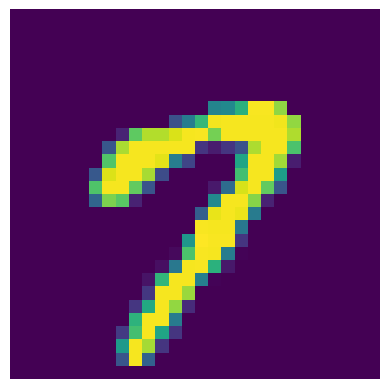

In [44]:
import matplotlib.pyplot as plt
plt.imshow(digit_predict,interpolation='nearest')
plt.axis("off")
plt.show()

In [45]:
y.iloc[15] #the number is 7

'7'

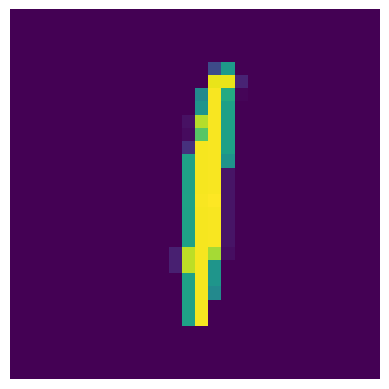

In [47]:
#to show the EVD

digit=x.iloc[112].to_numpy().reshape(28,28)#112th row from dataframe into an image
plt.imshow(digit,interpolation='nearest')
plt.axis("off") #hide the axis
plt.show()

In [54]:
L,U=np.linalg.eig(digit)

In [49]:
L

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        6.65516891e+02, -2.30911559e-14, -5.16891463e-01,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [50]:
np.sort(abs(L))[::-1] #sort the eigenvalues in descending order

array([6.65516891e+02, 5.16891463e-01, 2.30911559e-14, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

In [52]:
#one eigenvalue is big , while others are very small near zero
#energy is significant in only one direction as seen in the image of one

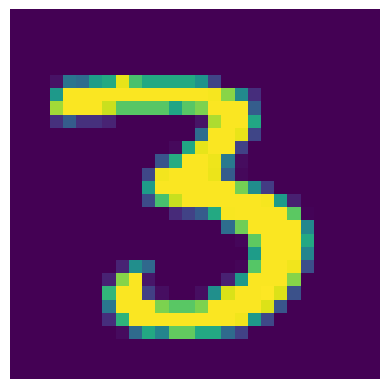

In [55]:
#take example of 3
#to show the EVD

digit=x.iloc[12].to_numpy().reshape(28,28)#12th row from dataframe into an image
plt.imshow(digit,interpolation='nearest')
plt.axis("off") #hide the axis
plt.show()

In [56]:
L,U=np.linalg.eig(digit)

In [57]:
np.sort(abs(L))[::-1] #sort the eigenvalues in descending order

array([1523.14887998,  726.82541788,  726.82541788,  441.95185999,
        441.95185999,  237.5045437 ,  171.9769542 ,  126.12735666,
         83.30810494,   83.30810494,   82.46967273,   71.40934318,
         51.02271779,   38.35169237,   33.88487555,   33.88487555,
         19.2523275 ,   19.2523275 ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ,
          0.        ,    0.        ,    0.        ,    0.        ])

In [58]:
#energy significant across 18 eigenvlues or direction as seen from three